In [1]:
from dotenv import load_dotenv
load_dotenv()
from langgraph.graph import START,END,StateGraph
from typing import  TypedDict
from langchain_ollama import ChatOllama

c:\projects\Langraph\.venv\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [ ]:
llm=ChatOllama(model='gemma4:31b-cloud' )

In [4]:
llm.invoke("Hello, how are you?")

AIMessage(content="I'm doing well, thank you for asking! How are you doing today? Is there anything I can help you with?", additional_kwargs={}, response_metadata={'model': 'gemma4:31b', 'created_at': '2026-07-01T06:51:44.333865291Z', 'done': True, 'done_reason': 'stop', 'total_duration': 400041857, 'load_duration': None, 'prompt_eval_count': 19, 'prompt_eval_duration': None, 'eval_count': 27, 'eval_duration': None, 'logprobs': None, 'model_name': 'gemma4:31b', 'model_provider': 'ollama'}, id='lc_run--019f1c72-a98c-7472-bcf8-b8714818c24e-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 19, 'output_tokens': 27, 'total_tokens': 46})

In [5]:
class BlogState(TypedDict):
   titleBlog:str
   outline:str
   blog:str
   score:float
   feedback:str


In [6]:
from langchain_core.messages import HumanMessage, SystemMessage

def blogoutline(state:BlogState)->BlogState:
    prompt=f"""
    You are an Professional Blog writer Genrate A Appropiate And Proper Blog outline on the give
    topic:{state['titleBlog']}

    """
    response=llm.invoke([
        HumanMessage(content="Genarete The Outline"),
        SystemMessage(content=prompt)
    ])
    state['outline']=response.content
    return state

In [7]:
from langchain_core.messages import HumanMessage, SystemMessage

def finalblog(state:BlogState)->BlogState:
    prompt=f"""
    You are an Professional Blog writer Genrate A Appropiate And Proper Blog on the given
    outline:{state['outline']}  and topic :{state['titleBlog']}

    """
    response=llm.invoke([
        HumanMessage(content="Generate the Blog "),
        SystemMessage(content=prompt)
    ])
    state['blog']=response.content
    return state

In [8]:
from pydantic import BaseModel

class Evaluation(BaseModel):
    score: float
    feedback: str

structured_llm = llm.with_structured_output(Evaluation)

In [9]:
def Score(state: BlogState):
    prompt = f"""
    Evaluate the following blog.

    Blog:
    {state['blog']}
    """

    result = structured_llm.invoke(prompt)

    state["score"] = result.score
    state["feedback"] = result.feedback

    return state

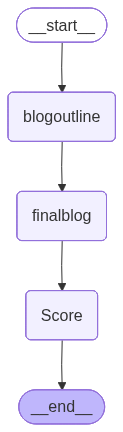

In [10]:
graph=StateGraph(BlogState)

graph.add_node("blogoutline",blogoutline)
graph.add_node("finalblog",finalblog)
graph.add_node("Score",Score)

graph.add_edge(START,'blogoutline')
graph.add_edge('blogoutline',"finalblog")
graph.add_edge("finalblog","Score")

graph.add_edge("Score",END)

workflow=graph.compile()
workflow

In [11]:
final_state=workflow.invoke({'titleBlog':"Chhtrapatti shivaji Maharaj"})

OutputParserException: Invalid json output: ### Overall Evaluation
The blog is **excellent**. It transcends a simple biographical summary and transforms into a piece of "thought-leadership" content. It successfully balances historical facts with modern application, making it engaging for both history buffs and general readers.

Below is a detailed breakdown of the evaluation based on key writing criteria:

---

### 1. Structure and Flow $\text{ (Score: 5/5)}$
The organization is logical and seamless. 
*   **The Hook:** Starting with a quote and a powerful introduction immediately sets an authoritative tone.
*   **The Narrative Arc:** It moves chronologically and thematically (Early Life $\rightarrow$ Philosophy $\rightarrow$ Key Events $\rightarrow$ Administration $\rightarrow$ Modern Relevance).
*   **Formatting:** The use of H1, H2, and H3 tags, along with bullet points and bold text, makes the piece highly "scannable," which is essential for digital readers.

### 2. Content and Dept

In [ ]:
print(final_state)

{'titleBlog': 'Chhtrapatti shivaji Maharaj', 'outline': 'Since you are looking for a professional blog outline, it is important to balance **historical accuracy** with **engaging storytelling**. Chhatrapati Shivaji Maharaj is not just a historical figure but a symbol of strategy, courage, and governance.\n\nDepending on your target audience, I have provided two options: one for a **Comprehensive Biography** (Long-form) and one for a **Leadership/Management** focus (Analytical).\n\n---\n\n### Option 1: The Comprehensive Biography\n*Best for: History enthusiasts, students, and general readers.*\n**Goal:** To provide a detailed chronological journey of his life.\n\n**Title Ideas:** \n* *The Eternal King: The Life and Legacy of Chhatrapati Shivaji Maharaj*\n* *The Architect of Swarajya: How Shivaji Maharaj Built a Great Empire*\n\n**I. Introduction**\n* **The Hook:** A powerful quote or a scene describing his coronation.\n* **Who was Shivaji Maharaj?** A brief overview of his identity as t

In [ ]:
print(final_state['outline'])

Since you are looking for a professional blog outline, it is important to balance **historical accuracy** with **engaging storytelling**. Chhatrapati Shivaji Maharaj is not just a historical figure but a symbol of strategy, courage, and governance.

Depending on your target audience, I have provided two options: one for a **Comprehensive Biography** (Long-form) and one for a **Leadership/Management** focus (Analytical).

---

### Option 1: The Comprehensive Biography
*Best for: History enthusiasts, students, and general readers.*
**Goal:** To provide a detailed chronological journey of his life.

**Title Ideas:** 
* *The Eternal King: The Life and Legacy of Chhatrapati Shivaji Maharaj*
* *The Architect of Swarajya: How Shivaji Maharaj Built a Great Empire*

**I. Introduction**
* **The Hook:** A powerful quote or a scene describing his coronation.
* **Who was Shivaji Maharaj?** A brief overview of his identity as the founder of the Maratha Empire.
* **The Core Philosophy:** Introduction

In [ ]:
print(final_state['blog'])

Since you provided two distinct directions—one historical and one analytical—I have developed a **comprehensive, high-authority blog post** that blends both. 

By merging the biography with leadership lessons, we create a piece of content that appeals to history buffs, students, and professionals alike. This approach maximizes SEO reach and reader engagement.

***

# The Architect of Swarajya: The Eternal Legacy of Chhatrapati Shivaji Maharaj

**By [Your Name/Company]**  
*Reading Time: 8 Minutes | Category: History & Leadership*

![Image Suggestion: A majestic image of Chhatrapati Shivaji Maharaj on his throne or a sweeping shot of Raigad Fort]

*"Freedom is a boon, which enhances the dignity of man."*

When we speak of Chhatrapati Shivaji Maharaj, we aren't just discussing a king from the 17th century; we are discussing a phenomenon. In an era dominated by massive empires like the Mughals and the Adil Shahi sultanate, a young man from the Sahyadri mountains dared to dream of **Swaraj

In [ ]:
print(final_state['score'])

As a Professional Blog Writer, I have evaluated your blog based on the outlines provided. 

Since you chose to **merge** Option 1 (Biography) and Option 2 (Leadership), you attempted a "Hybrid Approach." This is a sophisticated strategy because it attracts two different audiences (history buffs and professionals) simultaneously.

Here is the detailed evaluation:

### 🟢 Strengths (What worked well)
1.  **Structural Alignment:** You followed the logical flow of the outline perfectly. You moved from roots (Jijabai) $\rightarrow$ strategy (Guerilla warfare) $\rightarrow$ key events (Agra/Afzal Khan) $\rightarrow$ governance $\rightarrow$ modern application.
2.  **The "Bridge" Technique:** You did an excellent job of bridging history with modern business lessons. For example, comparing *Ganimi Kava* to a "lean startup disrupting a giant corporation" is a high-level writing technique that adds immense value to the reader.
3.  **Formatting & Readability:** The use of bolding, bullet points, a

In [ ]:
print(final_state['feedback'])